# **Name: Chirag Chaudhari**
# **Roll no: 24102A2003**
# **Branch: CMPN-A**

# **Lab 3: Control Flow for Data Cleaning**

In [1]:
# Install required packages
install.packages(c("dplyr", "readr", "microbenchmark"))

# Load libraries
library(dplyr)
library(readr)
library(microbenchmark)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
# Load UCI Heart Disease dataset

url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart_data <- read.csv(
  url,
  header = FALSE,
  na.strings = "?"
)

# Assign column names
colnames(heart_data) <- c(
  "age",
  "sex",
  "cp",
  "trestbps",
  "chol",
  "fbs",
  "restecg",
  "thalach",
  "exang",
  "oldpeak",
  "slope",
  "ca",
  "thal",
  "num"
)

# Display first few rows
head(heart_data)

# Display structure
str(heart_data)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ num     : int  0 2 1 0 0 0 3 0 2 1 ...


In [6]:
# Check resting blood pressure
summary(heart_data$trestbps)

# Check missing values
sum(is.na(heart_data$trestbps))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   94.0   120.0   130.0   131.7   140.0   200.0 

[1] 0

In [7]:
# Create a copy of the original dataset
heart_data_dirty <- heart_data

# Introduce negative BP values
heart_data_dirty$trestbps[1:3] <- c(-120, -80, -100)

# Introduce missing values
heart_data_dirty$trestbps[4:6] <- NA

# Introduce extreme BP values
heart_data_dirty$trestbps[7:9] <- c(320, 350, 400)

# Check the modified values
heart_data_dirty$trestbps[1:10]

[1] -120  -80 -100   NA   NA   NA  320  350  400  140

Create BP-cleaning function

In [8]:
clean_bp <- function(bp) {

  if (is.na(bp)) {
    return(NA)
  } else if (bp < 0) {
    return(NA)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

Test the function

In [9]:
# Test individual values
clean_bp(-120)
clean_bp(120)
clean_bp(320)
clean_bp(NA)

[1] NA

[1] 120

[1] 250

[1] NA

Apply function to entire BP column

In [10]:
heart_data_clean <- heart_data_dirty

heart_data_clean$trestbps <- sapply(
  heart_data_clean$trestbps,
  clean_bp
)

# View first 10 values
heart_data_clean$trestbps[1:10]

[1]  NA  NA  NA  NA  NA  NA 250 250 250 140

Error Handling with tryCatch()

In [11]:
safe_mean_bp <- function(bp) {

  tryCatch({

    mean_bp <- mean(bp, na.rm = TRUE)

    if (is.nan(mean_bp)) {
      stop("Mean BP cannot be calculated.")
    }

    return(mean_bp)

  }, error = function(e) {

    message("Error while calculating mean BP: ", e$message)
    return(NA)
  })
}

# Calculate mean BP
safe_mean_bp(heart_data_clean$trestbps)

[1] 132.8519

In [12]:
safe_ratio <- function(chol, bp) {

  tryCatch({

    if (is.na(chol) || is.na(bp)) {
      stop("Cholesterol or BP contains NA.")
    }

    if (bp == 0) {
      stop("BP cannot be zero.")
    }

    if (bp < 0) {
      stop("BP cannot be negative.")
    }

    ratio <- chol / bp

    return(ratio)

  }, error = function(e) {

    message("Invalid ratio: ", e$message)
    return(NA)
  })
}

In [13]:
# Valid case
safe_ratio(200, 120)

# BP = 0
safe_ratio(200, 0)

# BP = NA
safe_ratio(200, NA)

# Negative BP
safe_ratio(200, -100)

[1] 1.666667

Invalid ratio: BP cannot be zero.



[1] NA

Invalid ratio: Cholesterol or BP contains NA.



[1] NA

Invalid ratio: BP cannot be negative.



[1] NA

Loop vs Vectorized Cleaning

Loop-based cleaning

In [14]:
loop_clean <- function(bp) {

  cleaned <- bp

  for (i in seq_along(cleaned)) {

    if (is.na(cleaned[i])) {
      cleaned[i] <- NA

    } else if (cleaned[i] < 0) {
      cleaned[i] <- NA

    } else if (cleaned[i] > 250) {
      cleaned[i] <- 250
    }
  }

  return(cleaned)
}

Vectorized cleaning

In [15]:
vectorized_clean <- function(bp) {

  cleaned <- bp

  cleaned[cleaned < 0] <- NA
  cleaned[cleaned > 250] <- 250

  return(cleaned)
}

Test both approaches

In [16]:
loop_result <- loop_clean(heart_data_dirty$trestbps)

vectorized_result <- vectorized_clean(
  heart_data_dirty$trestbps
)

# Compare results
head(loop_result, 10)
head(vectorized_result, 10)

[1]  NA  NA  NA  NA  NA  NA 250 250 250 140

[1]  NA  NA  NA  NA  NA  NA 250 250 250 140

In [17]:
identical(loop_result, vectorized_result)

[1] TRUE

In [18]:
# Measure execution time

loop_time <- system.time({
  loop_result <- loop_clean(heart_data_dirty$trestbps)
})

vectorized_time <- system.time({
  vectorized_result <- vectorized_clean(
    heart_data_dirty$trestbps
  )
})

loop_time
vectorized_time

   user  system elapsed 
  0.000   0.000   0.001 

   user  system elapsed 
  0.004   0.000   0.004 

In [19]:
benchmark_result <- microbenchmark(

  Loop = loop_clean(heart_data_dirty$trestbps),

  Vectorized = vectorized_clean(
    heart_data_dirty$trestbps
  ),

  times = 100
)

print(benchmark_result)

summary(benchmark_result)

Unit: microseconds
       expr     min       lq     mean   median       uq     max neval
       Loop 115.051 142.2585 159.3216 155.2470 176.0785 230.696   100
 Vectorized   8.537   9.3215  12.8597   9.8545  11.4635  62.718   100


expr,min,lq,mean,median,uq,max,neval
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Loop,115.051,142.2585,159.3216,155.2470,176.0785,230.696,100
Vectorized,8.537,9.3215,12.8597,9.8545,11.4635,62.718,100


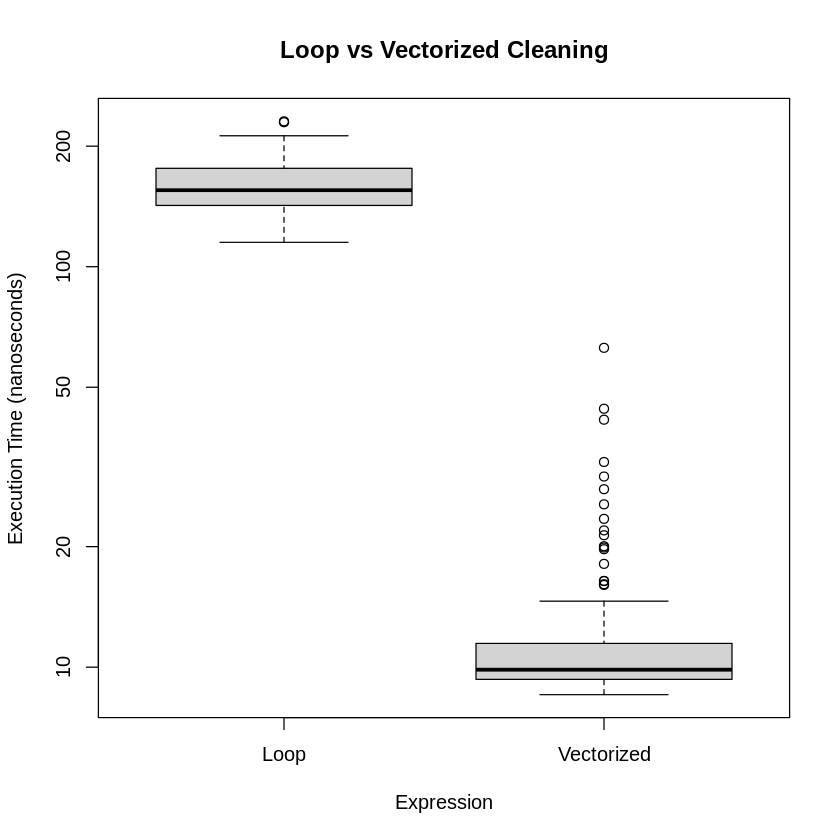

In [20]:
boxplot(
  benchmark_result,
  main = "Loop vs Vectorized Cleaning",
  ylab = "Execution Time (nanoseconds)"
)

In [21]:
# Count missing BP values

missing_bp <- sum(is.na(heart_data_clean$trestbps))

cat("Missing BP values:", missing_bp)

Missing BP values: 6

In [22]:
# Calculate minimum, maximum, mean and median

bp_min <- min(
  heart_data_clean$trestbps,
  na.rm = TRUE
)

bp_max <- max(
  heart_data_clean$trestbps,
  na.rm = TRUE
)

bp_mean <- mean(
  heart_data_clean$trestbps,
  na.rm = TRUE
)

bp_median <- median(
  heart_data_clean$trestbps,
  na.rm = TRUE
)

cat("Minimum BP:", bp_min, "\n")
cat("Maximum BP:", bp_max, "\n")
cat("Mean BP:", bp_mean, "\n")
cat("Median BP:", bp_median, "\n")

Minimum BP: 94 
Maximum BP: 250 
Mean BP: 132.8519 
Median BP: 130 


In [23]:
# Verify no invalid values remain

negative_values <- sum(
  heart_data_clean$trestbps < 0,
  na.rm = TRUE
)

values_above_250 <- sum(
  heart_data_clean$trestbps > 250,
  na.rm = TRUE
)

cat("Negative BP values:", negative_values, "\n")
cat("BP values > 250:", values_above_250, "\n")

Negative BP values: 0 
BP values > 250: 0 


In [24]:
cat("----- BP Cleaning Validation -----\n")
cat("Missing BP:", sum(is.na(heart_data_clean$trestbps)), "\n")
cat("Minimum BP:", min(heart_data_clean$trestbps, na.rm = TRUE), "\n")
cat("Maximum BP:", max(heart_data_clean$trestbps, na.rm = TRUE), "\n")
cat("Mean BP:", mean(heart_data_clean$trestbps, na.rm = TRUE), "\n")
cat("Median BP:", median(heart_data_clean$trestbps, na.rm = TRUE), "\n")
cat("Negative values:", sum(heart_data_clean$trestbps < 0, na.rm = TRUE), "\n")
cat("Values > 250:", sum(heart_data_clean$trestbps > 250, na.rm = TRUE), "\n")

----- BP Cleaning Validation -----
Missing BP: 6 
Minimum BP: 94 
Maximum BP: 250 
Mean BP: 132.8519 
Median BP: 130 
Negative values: 0 
Values > 250: 0 


In [25]:
write.csv(
  heart_data_clean,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.

In [27]:
file.copy(
  "cleaned_heart_data.csv",
  "/content/cleaned_heart_data.csv"
)

[1] FALSE


Conclusion:
The BP-cleaning function successfully identified negative and extreme
blood-pressure values and converted them according to the
specified rules. tryCatch() allowed invalid calculations to be handled
without terminating the program. Both loop-based and vectorized
approaches produced the same cleaned results. The execution-time
comparison demonstrates that vectorized operations are generally more
efficient than explicit loops for data-cleaning operations in R.
